# Phase 3 Step 3 — Controlled Nonlinear Model Challenger

This experiment evaluates exactly five predeclared `HistGradientBoostingClassifier` configurations on the frozen 16-feature Customer Return Risk design. Positive class 1 means zero baskets in `(T,T+28d]`, not contractual churn. **November lockbox outcomes are not accessed.**

## Objective and frozen methodology

Determine whether one lightweight nonlinear family improves pooled PR-AUC beyond the 0.4688 recency–frequency heuristic without severe September–October instability or catastrophic calibration degradation. Training is April–August only; September and October are unchanged forward validation.

In [1]:
from pathlib import Path
import io,sys,time,joblib
ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT/'src'))
import numpy as np,pandas as pd,pyreadr,matplotlib.pyplot as plt
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve,precision_score,recall_score,f1_score
from marketmind.return_risk.cohorts import build_labeled_cohort
from marketmind.return_risk.features import build_candidate_features,baseline_features,make_logistic_preprocessor,BASELINE_FEATURE_ORDER
from marketmind.return_risk.models import HGB_CANDIDATE_PARAMETERS,TRAINING_SNAPSHOTS,VALIDATION_SNAPSHOTS,LOCKBOX_SNAPSHOT,fit_hgb_candidate
from marketmind.return_risk.evaluation import score_metrics,capacity_metrics,calibration_bins,clustered_bootstrap_auc
pd.set_option('display.max_columns',40)
RAW=ROOT/'data'/'raw'/'complete_journey'; ART=ROOT/'reports'/'return_risk'/'artifacts'; FIG=ROOT/'reports'/'return_risk'/'figures'
ART.mkdir(parents=True,exist_ok=True);FIG.mkdir(parents=True,exist_ok=True)
assert len(HGB_CANDIDATE_PARAMETERS)==5
assert LOCKBOX_SNAPSHOT not in (*TRAINING_SNAPSHOTS,*VALIDATION_SNAPSHOTS)

## Benchmark context and model rationale

The heuristic has pooled PR-AUC 0.4688; unweighted Logistic has PR-AUC 0.4586, ROC-AUC 0.8508, and Brier 0.0929. HGB can represent nonlinearities/interactions with the existing sklearn dependency. No other nonlinear family, feature extension, resampling, or class weight is used.

## Fixed candidate configurations

In [2]:
pd.DataFrame(HGB_CANDIDATE_PARAMETERS).T

,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,l2_regularization,early_stopping,random_state
HGB-1,0.05,150,15,50,1.0,False,42
HGB-2,0.05,200,31,50,1.0,False,42
HGB-3,0.03,250,31,50,1.0,False,42
HGB-4,0.05,200,31,100,1.0,False,42
HGB-5,0.05,200,15,50,5.0,False,42


## Training setup and missingness

The authentic data is rebuilt point-in-time for April–October only. HGB receives raw engineered values—no Logistic transform or scaling. The utility rejects any non-training snapshot during fit.

In [3]:
transactions=pyreadr.read_r(str(RAW/'transactions.rds'))[None]; products=pyreadr.read_r(str(RAW/'products.rda'))['products'];transactions.transaction_timestamp=pd.to_datetime(transactions.transaction_timestamp)
frames=[]
for snapshot in (*TRAINING_SNAPSHOTS,*VALIDATION_SNAPSHOTS):
    f=baseline_features(build_candidate_features(transactions,products,snapshot))
    y=build_labeled_cohort(transactions,snapshot,28,'2017-12-31 23:59:59')[['return_risk_target']]
    z=f.join(y,validate='one_to_one').reset_index();z['snapshot_at']=snapshot;frames.append(z)
data=pd.concat(frames,ignore_index=True); assert data.snapshot_at.max()==VALIDATION_SNAPSHOTS[-1]
train=data[data.snapshot_at.isin(TRAINING_SNAPSHOTS)].copy();validation=data[data.snapshot_at.isin(VALIDATION_SNAPSHOTS)].copy()
X_train=train.loc[:,BASELINE_FEATURE_ORDER];y_train=train.return_risk_target;X_valid=validation.loc[:,BASELINE_FEATURE_ORDER];y_valid=validation.return_risk_target
missing=pd.DataFrame({'training_missing':X_train.isna().sum(),'validation_missing':X_valid.isna().sum()});display(missing.T)
assert missing.to_numpy().sum()==0 and len(train)==10223 and len(validation)==4529

,recency_days,basket_frequency_lifetime,monetary_lifetime,average_basket_value,baskets_last_7d,baskets_last_28d,spend_last_28d,median_days_between_baskets,std_days_between_baskets,active_span_days,unique_departments,department_spend_hhi,discount_share_of_gross,coupon_basket_rate,baskets_28d_change,spend_28d_change
training_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
validation_missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Model training, temporal validation, and compute

Each model is fit once on April–August and scored unchanged on September, October, and pooled validation. Serialized sizes are in-memory research estimates; no production artifact is saved.

In [4]:
models={};scores={};compute=[];rows=[]
for name in HGB_CANDIDATE_PARAMETERS:
    started=time.perf_counter();model=fit_hgb_candidate(name,X_train,y_train,train.snapshot_at);fit_seconds=time.perf_counter()-started
    started=time.perf_counter();score=model.predict_proba(X_valid)[:,1];prediction_seconds=time.perf_counter()-started
    buffer=io.BytesIO();joblib.dump(model,buffer);size_kib=len(buffer.getvalue())/1024
    models[name]=model;scores[name]=score;compute.append({'candidate':name,'fit_seconds':fit_seconds,'prediction_seconds':prediction_seconds,'serialized_kib':size_kib})
    for cohort,date in [('September','2017-09-30'),('October','2017-10-31'),('Pooled',None)]:
        mask=np.ones(len(validation),bool) if date is None else validation.snapshot_at.dt.date==pd.Timestamp(date).date()
        result=score_metrics(y_valid[mask],score[mask]);rows.append({'candidate':name,'cohort':cohort,**result})
metrics=pd.DataFrame(rows);compute=pd.DataFrame(compute);metrics.to_csv(ART/'hgb_candidate_metrics.csv',index=False);compute.to_csv(ART/'hgb_compute.csv',index=False)
display(metrics.drop(columns=['confusion_matrix','precision_at_0_5','recall_at_0_5','f1_at_0_5']).round(5));display(compute.round(4))

,candidate,cohort,n,prevalence,pr_auc,roc_auc,log_loss,brier
0,HGB-1,September,2247,0.13796,0.48439,0.86626,0.28590,0.08902
1,HGB-1,October,2282,0.13804,0.45312,0.84870,0.30036,0.09360
2,HGB-1,Pooled,4529,0.13800,0.46720,0.85735,0.29319,0.09133
3,HGB-2,September,2247,0.13796,0.45608,0.85853,0.29633,0.09237
4,HGB-2,October,2282,0.13804,0.42778,0.84412,0.30932,0.09582
5,HGB-2,Pooled,4529,0.13800,0.44123,0.85121,0.30288,0.09411
6,HGB-3,September,2247,0.13796,0.45958,0.86088,0.29239,0.09151
7,HGB-3,October,2282,0.13804,0.43887,0.84559,0.30540,0.09488
8,HGB-3,Pooled,4529,0.13800,0.44787,0.85314,0.29894,0.09321
9,HGB-4,September,2247,0.13796,0.46376,0.86036,0.29574,0.09174


,candidate,fit_seconds,prediction_seconds,serialized_kib
0,HGB-1,0.5175,0.0077,290.5625
1,HGB-2,0.9063,0.0101,728.8438
2,HGB-3,1.1947,0.0151,904.6250
3,HGB-4,0.8538,0.0115,728.8438
4,HGB-5,0.4775,0.0124,378.8438


## Predeclared model-selection decision

Promising requires pooled PR-AUC > 0.4688, no severe temporal instability, and calibration not catastrophically worse than unweighted Logistic. Candidates within 1% relative PR-AUC prefer the simpler/smaller configuration unless temporal stability clearly favors another.

In [5]:
pooled=metrics[metrics.cohort.eq('Pooled')].set_index('candidate');best_pr=pooled.pr_auc.max();within=pooled[pooled.pr_auc>=best_pr/1.01]
# Complexity preference is lower leaf count, then fewer iterations, then candidate order.
best=min(within.index,key=lambda n:(HGB_CANDIDATE_PARAMETERS[n]['max_leaf_nodes'],HGB_CANDIDATE_PARAMETERS[n]['max_iter'],n))
heuristic_benchmark=0.46878013835124294
comparison=pd.DataFrame({'hgb':pooled.loc[best,['pr_auc','roc_auc','brier','log_loss']],
 'heuristic':pd.Series({'pr_auc':heuristic_benchmark,'roc_auc':0.845946106557377}),
 'unweighted_logistic':pd.Series({'pr_auc':0.45861815097909864,'roc_auc':0.8507561475409836,'brier':0.09286107315199993,'log_loss':0.29796547385741534})})
display(pd.Series({'selected':best,'best_raw_pr_candidate':pooled.pr_auc.idxmax(),'absolute_vs_heuristic':pooled.loc[best,'pr_auc']-heuristic_benchmark,'relative_vs_heuristic_pct':(pooled.loc[best,'pr_auc']/heuristic_benchmark-1)*100}));display(comparison.round(5))

selected                        HGB-1
best_raw_pr_candidate           HGB-1
absolute_vs_heuristic       -0.001585
relative_vs_heuristic_pct   -0.338095
dtype: object

,hgb,heuristic,unweighted_logistic
brier,0.09133,NaN,0.09286
log_loss,0.29319,NaN,0.29797
pr_auc,0.46720,0.46878,0.45862
roc_auc,0.85735,0.84595,0.85076


## Household-clustered bootstrap intervals

Three hundred deterministic household-cluster resamples retain repeated snapshots together.

In [6]:
intervals=clustered_bootstrap_auc(validation.assign(score=scores[best]),household_column='household_id',target_column='return_risk_target',score_column='score',n_bootstrap=300);intervals

{'pr_auc_95ci': (0.4219070436593929, 0.5091570943991611),
 'roc_auc_95ci': (0.8412525667520544, 0.8710849902623675)}

## Calibration diagnostics and temporal score shift

Raw HGB outputs are uncalibrated probability estimates/risk scores. No calibrator is fitted. Month-specific quantile bins diagnose both ranking and calibration changes.

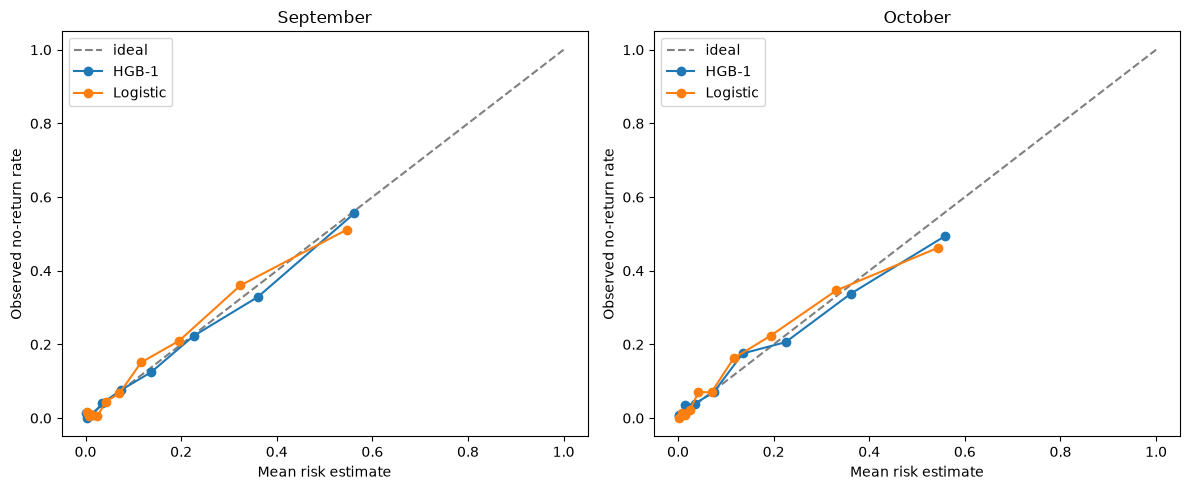

,mean_score,observed_rate,model,cohort
0,0.0012,0.0133,HGB-1,September
1,0.0027,0.0000,HGB-1,September
2,0.0063,0.0089,HGB-1,September
3,0.0142,0.0089,HGB-1,September
4,0.0349,0.0400,HGB-1,September
5,0.0738,0.0759,HGB-1,September
6,0.1371,0.1244,HGB-1,September
7,0.2262,0.2232,HGB-1,September
8,0.3605,0.3289,HGB-1,September
9,0.5621,0.5556,HGB-1,September


,count,mean,std,min,10%,25%,50%,75%,90%,max
snapshot_at,,,,,,,,,,
2017-09-30 23:59:59,2247.0,0.1420,0.1822,0.0007,0.0018,0.0064,0.0535,0.2251,0.4558,0.8368
2017-10-31 23:59:59,2282.0,0.1415,0.1811,0.0007,0.0018,0.0061,0.0512,0.2259,0.4532,0.8332


In [7]:
# Refit the frozen unweighted Logistic reference for direct development comparison only.
logistic=Pipeline([('preprocess',make_logistic_preprocessor()),('model',LogisticRegression(class_weight=None,solver='lbfgs',max_iter=2000,random_state=42))]).fit(X_train,y_train)
logistic_score=logistic.predict_proba(X_valid)[:,1]
cal=[]
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,(label,date) in zip(axes,[('September','2017-09-30'),('October','2017-10-31')]):
    mask=validation.snapshot_at.dt.date==pd.Timestamp(date).date();ax.plot([0,1],[0,1],'--',color='grey',label='ideal')
    for name,score in [(best,scores[best]),('Logistic',logistic_score)]:
        bins=calibration_bins(y_valid[mask],score[mask],10).assign(model=name,cohort=label);cal.append(bins);ax.plot(bins.mean_score,bins.observed_rate,marker='o',label=name)
    ax.set(title=label,xlabel='Mean risk estimate',ylabel='Observed no-return rate');ax.legend()
fig.tight_layout();fig.savefig(FIG/'hgb_calibration_by_month.png',dpi=160);plt.show()
calibration=pd.concat(cal,ignore_index=True);calibration.to_csv(ART/'hgb_calibration_bins.csv',index=False);display(calibration.round(4))
shift=validation.assign(score=scores[best]).groupby('snapshot_at').score.describe(percentiles=[.1,.25,.5,.75,.9]);shift.to_csv(ART/'hgb_score_shift.csv');display(shift.round(4))

## Capacity metrics and threshold diagnostics

Capacity results compare the selected HGB, unweighted Logistic, and the frozen heuristic. Thresholds are descriptive only and are not selected.

,capacity,selected,positives_captured,precision,recall,model
0,0.05,227,128,0.5639,0.2048,HGB-1
1,0.10,453,236,0.5210,0.3776,HGB-1
2,0.20,906,389,0.4294,0.6224,HGB-1
3,0.05,227,129,0.5683,0.2064,Logistic
4,0.10,453,223,0.4923,0.3568,Logistic
5,0.20,906,381,0.4205,0.6096,Logistic
6,0.05,227,135,0.5947,0.2160,Heuristic
7,0.10,453,245,0.5408,0.3920,Heuristic
8,0.20,906,379,0.4183,0.6064,Heuristic


,threshold,selected,precision,recall,f1
0,0.1,1816,0.3056,0.8880,0.4547
1,0.2,1258,0.3712,0.7472,0.4960
2,0.3,845,0.4414,0.5968,0.5075
3,0.4,580,0.4948,0.4592,0.4763
4,0.5,342,0.5322,0.2912,0.3764


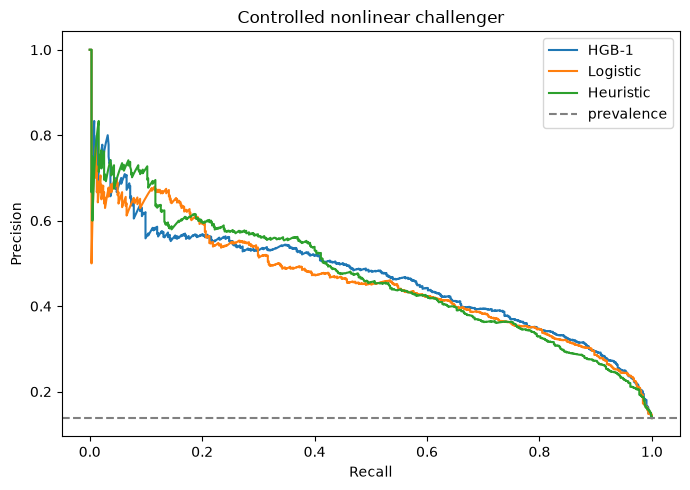

In [8]:
lf=np.log1p(train.basket_frequency_lifetime);rm,rs=train.recency_days.mean(),train.recency_days.std(ddof=0);fm,fs=lf.mean(),lf.std(ddof=0)
heuristic_score=expit((validation.recency_days-rm)/rs-(np.log1p(validation.basket_frequency_lifetime)-fm)/fs)
caps=[]
for name,score in [(best,scores[best]),('Logistic',logistic_score),('Heuristic',heuristic_score)]:caps.append(capacity_metrics(y_valid,score).assign(model=name))
capacity=pd.concat(caps,ignore_index=True);capacity.to_csv(ART/'hgb_capacity_comparison.csv',index=False);display(capacity.round(4))
threshold=[]
for value in (.10,.20,.30,.40,.50):
    pred=scores[best]>=value;threshold.append({'threshold':value,'selected':int(pred.sum()),'precision':precision_score(y_valid,pred,zero_division=0),'recall':recall_score(y_valid,pred,zero_division=0),'f1':f1_score(y_valid,pred,zero_division=0)})
threshold=pd.DataFrame(threshold);threshold.to_csv(ART/'hgb_threshold_diagnostics.csv',index=False);display(threshold.round(4))
fig,ax=plt.subplots(figsize=(7,5))
for name,score in [(best,scores[best]),('Logistic',logistic_score),('Heuristic',heuristic_score)]:
    precision,recall,_=precision_recall_curve(y_valid,score);ax.plot(recall,precision,label=name)
ax.axhline(y_valid.mean(),ls='--',color='grey',label='prevalence');ax.set(xlabel='Recall',ylabel='Precision',title='Controlled nonlinear challenger');ax.legend();fig.tight_layout();fig.savefig(FIG/'hgb_precision_recall.png',dpi=160);plt.show()

## Temporal stability and error analysis

Profiles are medians and contain no household identifiers. The 0.5 threshold is diagnostic only; lower-score false negatives are the missed positive cases.

In [9]:
error=validation.copy();error['score']=scores[best];error['prediction']=(error.score>=.5).astype(int);error['error_type']=np.select([(error.return_risk_target.eq(1)&error.prediction.eq(1)),(error.return_risk_target.eq(0)&error.prediction.eq(1)),(error.return_risk_target.eq(0)&error.prediction.eq(0))],['TP','FP','TN'],default='FN')
error_profiles=error.groupby('error_type')[list(BASELINE_FEATURE_ORDER)+['score']].median();error_profiles.to_csv(ART/'hgb_error_profiles.csv');display(error.error_type.value_counts());display(error_profiles.round(3))
for label,date in [('September','2017-09-30'),('October','2017-10-31')]:
    mask=validation.snapshot_at.dt.date==pd.Timestamp(date).date();display(label,calibration_bins(y_valid[mask],scores[best][mask],5).round(4))

error_type
TN    3744
FN     443
TP     182
FP     160
Name: count, dtype: int64

,recency_days,basket_frequency_lifetime,monetary_lifetime,average_basket_value,baskets_last_7d,baskets_last_28d,spend_last_28d,median_days_between_baskets,std_days_between_baskets,active_span_days,unique_departments,department_spend_hhi,discount_share_of_gross,coupon_basket_rate,baskets_28d_change,spend_28d_change,score
error_type,,,,,,,,,,,,,,,,,
FN,13.0,17.0,439.070,24.641,0.0,1.0,20.300,8.205,14.187,249.0,9.0,0.344,0.155,0.000,0.0,0.000,0.259
FP,65.0,9.0,188.495,18.884,0.0,0.0,0.000,15.412,22.695,211.5,7.0,0.362,0.132,0.000,0.0,0.000,0.562
TN,3.0,45.0,1288.320,27.817,1.0,4.0,120.505,4.197,5.918,269.0,11.0,0.334,0.150,0.032,0.0,0.495,0.025
TP,75.0,8.0,193.590,20.478,0.0,0.0,0.000,13.006,20.882,185.0,7.0,0.384,0.141,0.000,0.0,0.000,0.574


'September'

,mean_score,observed_rate
0,0.0020,0.0067
1,0.0102,0.0089
2,0.0543,0.0579
3,0.1816,0.1737
4,0.4613,0.4422


'October'

,mean_score,observed_rate
0,0.0020,0.0066
1,0.0104,0.0219
2,0.0549,0.0548
3,0.1802,0.1908
4,0.4597,0.4158


## Model-selection decision, limitations, and next decision

The predeclared rule is applied without expanding the candidate grid. Results determine whether the family is sufficiently promising to freeze for later threshold/calibration work. Feature importance tooling is intentionally omitted. The short grocery panel, household dependence, temporal change, and observational features limit generalization and causal interpretation. Any feature extension requires a clear residual signal and a separately authorized experiment. November remains sealed.